The aim of this notebook is testing some parts of our Grid2op project.

C:\Users\lbl03\AppData\Local\Temp\ipykernel_6252\2542271111.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\lbl03\AppData\Local\Temp\ipykernel_6252\2542271111.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_custom.show()


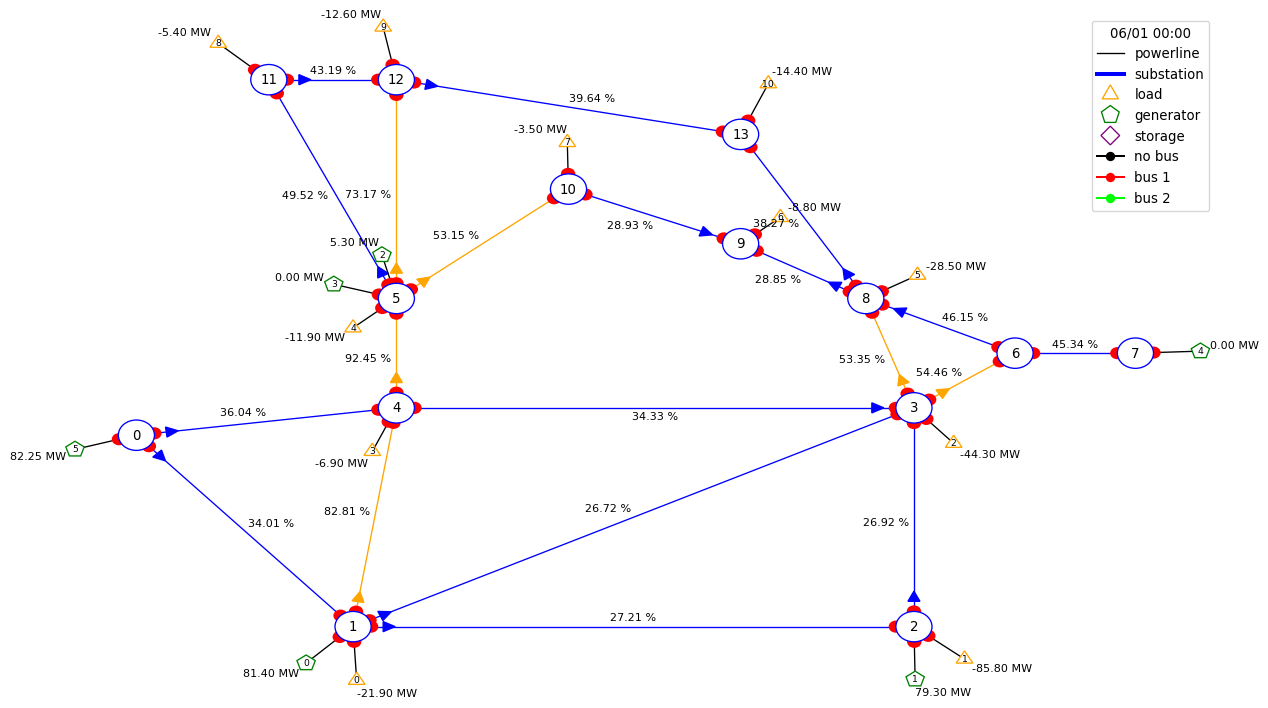

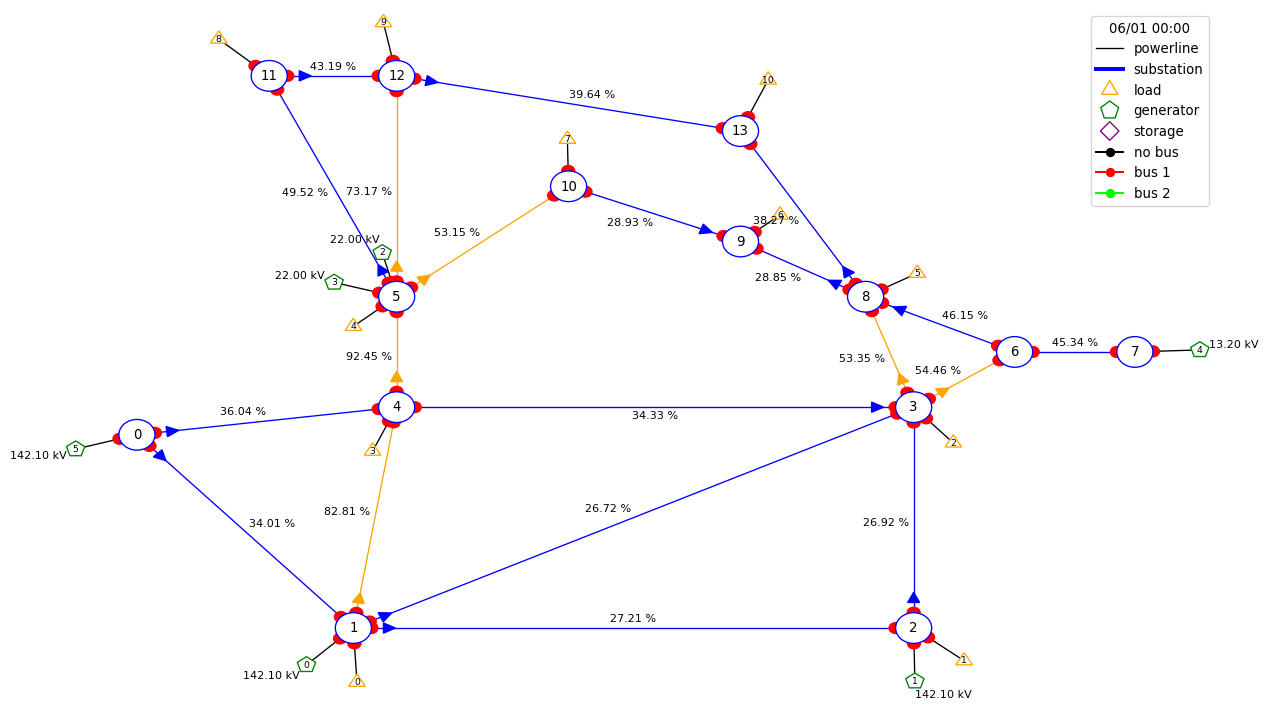

In [3]:
import grid2op
from grid2op.PlotGrid import PlotMatplot

env = grid2op.make("l2rpn_case14_sandbox")
plot_helper = PlotMatplot(env.observation_space)

obs = env.reset()

# if you want to plot all the observation
fig = plot_helper.plot_obs(obs)
fig.show()

# you can also chose what to plot for each "object type"
fig_custom = plot_helper.plot_obs(obs
                                  line_info="rho",
                                  load_info=None,  # i don't plot anything concerning the load
                                  gen_info="v"  # i draw the voltage setpoint of the generators
                                  )
fig_custom.show()

C:\Users\lbl03\AppData\Local\Temp\ipykernel_8800\1290949492.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


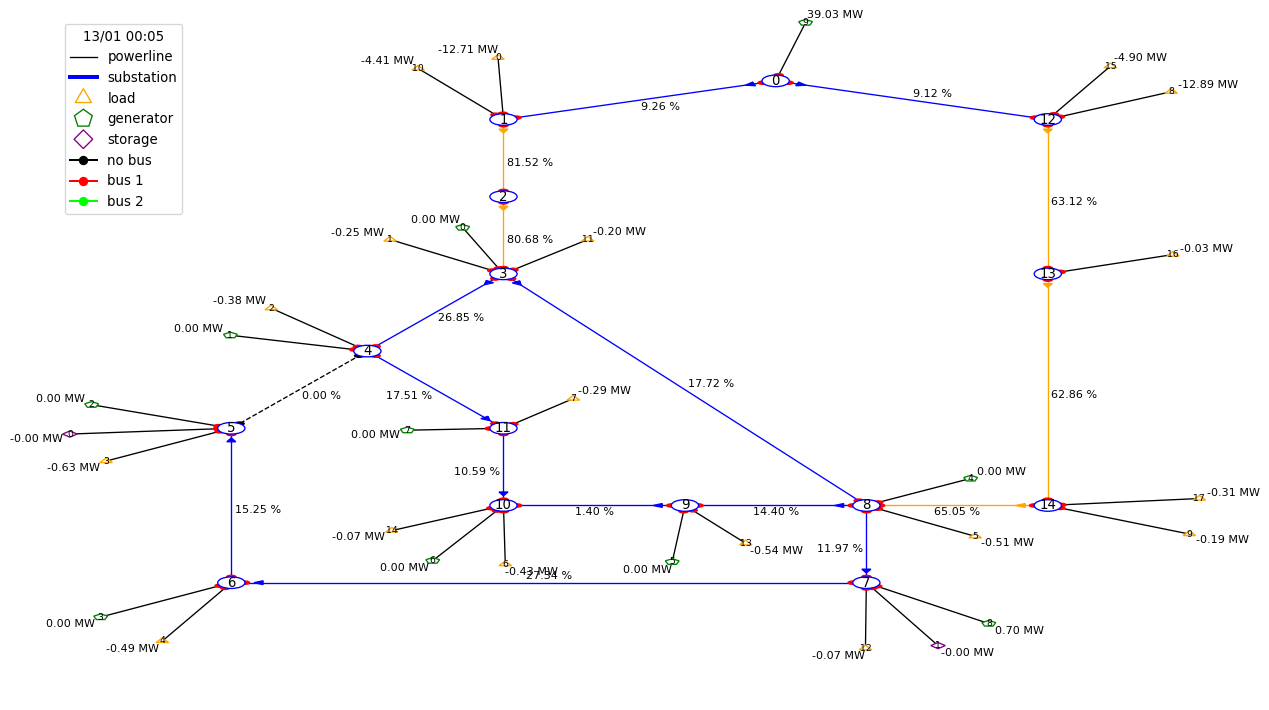

In [6]:
import grid2op
from grid2op.PlotGrid import PlotMatplot

# 指定本地模型的完整路径（注意斜杠方向）
env = grid2op.make(
    dataset=r"E:\202504\2140prj\l2rpn_case14_storage_\l2rpn_case14_storage_train"  # 直接使用 dataset 参数
)
plot_helper = PlotMatplot(env.observation_space)

# 指定使用特定的 scenario
time_series_id = "Scenario_4"  # 替换为你想加载的具体场景ID
obs = env.reset(options={"time serie id": time_series_id})

# 继续绘制图像
fig = plot_helper.plot_obs(obs)
fig.show()


C:\Users\lbl03\AppData\Local\Temp\ipykernel_11032\2988062968.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_info.show()


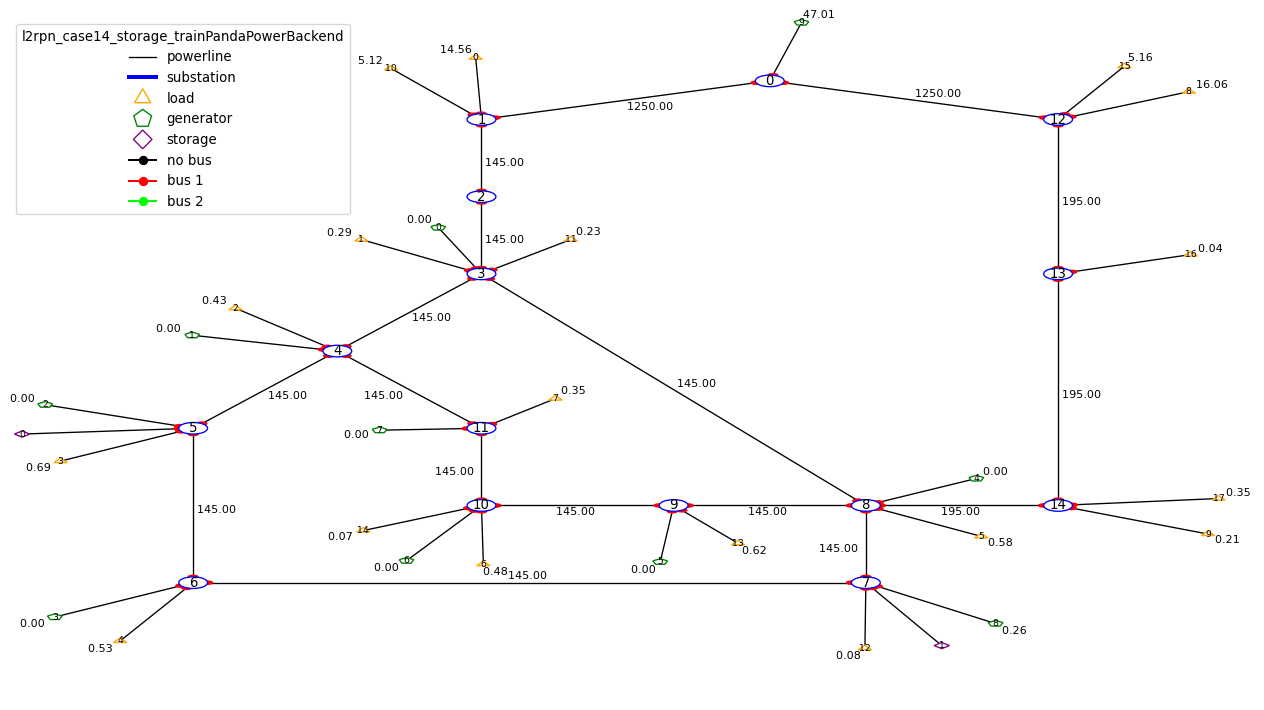

In [3]:
import grid2op
from grid2op.PlotGrid import PlotMatplot

# 创建环境
env = grid2op.make(
    dataset=r"E:\202504\2140prjE\l2rpn_case14_storage_\l2rpn_case14_storage_train"
)

plot_helper = PlotMatplot(env.observation_space)

# 获取当前观察（默认是初始化状态）
obs = env.reset()

# 获取线路热限制（thermal limits）和发电机功率（生成功率）
thermal_limits = env.get_thermal_limit()
gen_p = obs.gen_p  # 发电机当前功率（单位 MW）
load_p = obs.load_p #负载（单位MW）

# 使用 plot_info 加入 gen_values 参数以显示发电机信息
fig_info = plot_helper.plot_info(
    line_values=thermal_limits,
    gen_values=gen_p,
    load_values=load_p
)

fig_info.show()

In [2]:
import matplotlib
matplotlib.use('Agg')  # 在导入其他库前设置
import os
import warnings
import grid2op
from grid2op.Episode import EpisodeReplay
from grid2op.Agent import RandomAgent
from grid2op.Runner import Runner
from tqdm import tqdm

# 创建保存路径
path_agents = "agent_pseudo_random"
os.makedirs(path_agents, exist_ok=True)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    env = grid2op.make(dataset=r"E:\202504\2140prjE\l2rpn_case14_storage_\l2rpn_case14_storage_train")

class CustomRandom(RandomAgent):
    def __init__(self, action_space):
        super().__init__(action_space)
        self.i = 0

    def my_act(self, transformed_observation, reward, done=False):
        if self.i % 10 != 0:
            res = 0
        else:
            res = self.action_space.sample()
        self.i += 1
        return res

# 运行代理并保存结果
runner = Runner(**env.get_params_for_runner(), agentClass=CustomRandom)
path_agent = os.path.join(path_agents, "RandomAgent")
os.makedirs(path_agent, exist_ok=True)  # 确保子目录存在
res = runner.run(nb_episode=1, path_save=path_agent, pbar=tqdm, agent_seeds=[0])

# 生成GIF并关闭图形
plot_epi = EpisodeReplay(path_agent)
plot_epi.replay_episode(res[0][1], gif_name="episode")

# 可选：清理内存
import matplotlib.pyplot as plt
plt.close('all')

episode: 100%|██████████| 1/1 [00:00<00:00,  2.14it/s]
C:\Users\lbl03\anaconda3\envs\Grid2op\Lib\site-packages\grid2op\Episode\EpisodeReplay.py:167: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\lbl03\anaconda3\envs\Grid2op\Lib\site-packages\grid2op\Episode\EpisodeReplay.py:207: UserWarning: Failed to optimize .GIF size, but gif is still saved:
Install dependencies to reduce size by ~3 folds
apt-get install gifsicle && pip3 install pygifsicle
  warnings.warn(warn_msg)
